NADEEN

# Member A — Logistic Regression + Feature Engineering
Same cleaning/encoding **approach** as the original notebook — only fixed:
1. The encoder is fit **once** and reused for the feature-engineered model (no re-encoding, no second split).
2. Each part is organized into clear steps, with prints/plots showing the details at every stage.

## Step 1: Imports

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
)

## Step 2: Load & Understand the Data

In [12]:
df = pd.read_csv("aug_train.csv")

print("Shape:", df.shape)
print("\nMissing values per column:")
print(df.isnull().sum())

Shape: (19158, 14)

Missing values per column:
enrollee_id                  0
city                         0
city_development_index       0
gender                    4508
relevent_experience          0
enrolled_university        386
education_level            460
major_discipline          2813
experience                  65
company_size              5938
company_type              6140
last_new_job               423
training_hours               0
target                       0
dtype: int64


## Step 3: Handle Missing Values
- Low-missingness columns → fill with **mode**
- High-missingness columns → fill with **"Unknown"**

In [13]:
df_clean = df.copy()

mode_columns = ["enrolled_university", "education_level", "experience", "last_new_job"]
for col in mode_columns:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

unknown_columns = ["gender", "major_discipline", "company_size", "company_type"]
for col in unknown_columns:
    df_clean[col] = df_clean[col].fillna("Unknown")

print("Missing values after cleaning:")
print(df_clean.isnull().sum())
print("\nTotal missing values left:", df_clean.isnull().sum().sum())

Missing values after cleaning:
enrollee_id               0
city                      0
city_development_index    0
gender                    0
relevent_experience       0
enrolled_university       0
education_level           0
major_discipline          0
experience                0
company_size              0
company_type              0
last_new_job              0
training_hours            0
target                    0
dtype: int64

Total missing values left: 0


## Step 4: Define X / y and Split into Train/Test

In [14]:
X = df_clean.drop(columns=["target", "enrollee_id"])
y = df_clean["target"]
print("X shape:", X.shape, " y shape:", y.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("X_train:", X_train.shape, " X_test:", X_test.shape)

X shape: (19158, 12)  y shape: (19158,)
X_train: (15326, 12)  X_test: (3832, 12)


## Step 5: Separate Categorical and Numerical Columns

In [15]:
categorical_columns = X.select_dtypes(include=["object"]).columns.tolist()
numerical_columns = X.select_dtypes(exclude=["object"]).columns.tolist()

print("Categorical columns:", categorical_columns)
print("Numerical columns:  ", numerical_columns)

Categorical columns: ['city', 'gender', 'relevent_experience', 'enrolled_university', 'education_level', 'major_discipline', 'experience', 'company_size', 'company_type', 'last_new_job']
Numerical columns:   ['city_development_index', 'training_hours']


## Step 6: Encode Categorical Columns
This encoder is fit here a single time and **reused** later for the feature-engineered model in Step 10 — it is never re-fit.

In [16]:
encoder = OneHotEncoder(handle_unknown="ignore", drop="first", sparse_output=False)
encoder.fit(X_train[categorical_columns])

X_train_cat = pd.DataFrame(
    encoder.transform(X_train[categorical_columns]),
    index=X_train.index, columns=encoder.get_feature_names_out(categorical_columns),
)
X_test_cat = pd.DataFrame(
    encoder.transform(X_test[categorical_columns]),
    index=X_test.index, columns=encoder.get_feature_names_out(categorical_columns),
)

X_train_encoded = pd.concat([X_train_cat, X_train[numerical_columns]], axis=1)
X_test_encoded = pd.concat([X_test_cat, X_test[numerical_columns]], axis=1)

X_train_encoded.columns = X_train_encoded.columns.astype(str)
X_test_encoded.columns = X_test_encoded.columns.astype(str)

print("X_train_encoded:", X_train_encoded.shape)
print("X_test_encoded: ", X_test_encoded.shape)

X_train_encoded: (15326, 179)
X_test_encoded:  (3832, 179)


/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


## Step 7: Train the Baseline Logistic Regression Model

In [17]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_encoded, y_train)
print("Baseline model trained successfully!")

Baseline model trained successfully!


## Step 8: Evaluate the Baseline Model

In [18]:
y_pred = model.predict(X_test_encoded)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("=== Baseline Logistic Regression - Metrics ===")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-score :", f1)

=== Baseline Logistic Regression - Metrics ===
Accuracy : 0.7823590814196242
Precision: 0.5983739837398374
Recall   : 0.38534031413612563
F1-score : 0.46878980891719746


Confusion Matrix:
 [[2630  247]
 [ 587  368]]


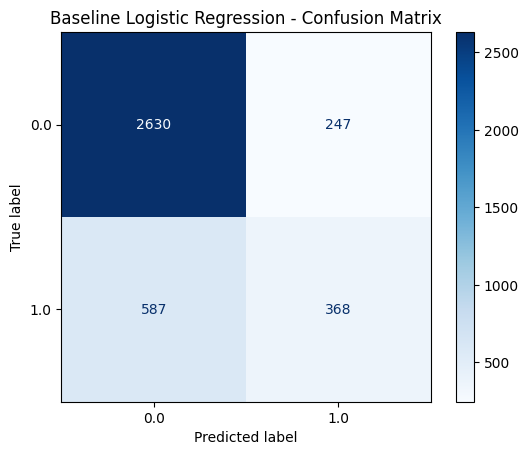

In [19]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap="Blues")
plt.title("Baseline Logistic Regression - Confusion Matrix")
plt.show()

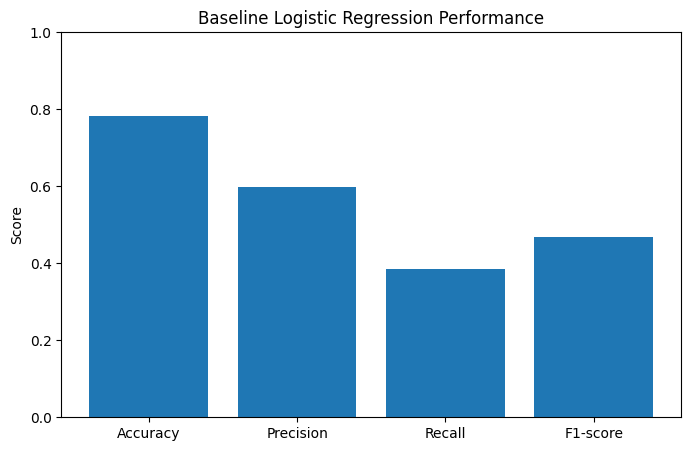

In [20]:
baseline_metrics = {"Accuracy": accuracy, "Precision": precision, "Recall": recall, "F1-score": f1}

plt.figure(figsize=(8, 5))
plt.bar(baseline_metrics.keys(), baseline_metrics.values())
plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("Baseline Logistic Regression Performance")
plt.show()

## Step 9 (Bonus): Feature Engineering
Built directly on the **already-split** `X_train` / `X_test` — no new split, no new categorical column list, no new encoder.

In [21]:
experience_num_train = X_train["experience"].replace({"<1": 0, ">20": 21, "Unknown": 0}).astype(float)
experience_num_test = X_test["experience"].replace({"<1": 0, ">20": 21, "Unknown": 0}).astype(float)

X_train_fe_num = X_train[numerical_columns].copy()
X_test_fe_num = X_test[numerical_columns].copy()

X_train_fe_num["experience_to_training_ratio"] = experience_num_train / (X_train["training_hours"] + 1)
X_test_fe_num["experience_to_training_ratio"] = experience_num_test / (X_test["training_hours"] + 1)

X_train_fe_num["has_relevant_degree"] = (X_train["major_discipline"] == "STEM").astype(int)
X_test_fe_num["has_relevant_degree"] = (X_test["major_discipline"] == "STEM").astype(int)

print("New engineered feature preview (train):")
X_train_fe_num[["experience_to_training_ratio", "has_relevant_degree"]].head(10)

New engineered feature preview (train):


,experience_to_training_ratio,has_relevant_degree
17855,0.109890,1
17664,0.312500,0
13404,0.324324,1
13366,0.092593,1
15670,0.031447,1
3857,0.137255,1
17115,0.000000,1
11516,0.400000,1
9457,1.583333,1
12825,0.020513,1


## Step 10: Build the Feature-Engineered Matrix — Reusing the Same Encoding
No re-encoding here: same one-hot columns from Step 6 (`X_train_cat` / `X_test_cat`), just extended with the two new numeric columns from Step 9.

In [22]:
X_train_encoded_fe = pd.concat([X_train_cat, X_train_fe_num], axis=1)
X_test_encoded_fe = pd.concat([X_test_cat, X_test_fe_num], axis=1)

X_train_encoded_fe.columns = X_train_encoded_fe.columns.astype(str)
X_test_encoded_fe.columns = X_test_encoded_fe.columns.astype(str)

print("X_train_encoded_fe:", X_train_encoded_fe.shape)
print("X_test_encoded_fe: ", X_test_encoded_fe.shape)

X_train_encoded_fe: (15326, 181)
X_test_encoded_fe:  (3832, 181)


## Step 11: Train & Evaluate the Feature-Engineered Model

In [23]:
model_fe = LogisticRegression(max_iter=1000)
model_fe.fit(X_train_encoded_fe, y_train)
print("Feature-engineered model trained successfully!")

y_pred_fe = model_fe.predict(X_test_encoded_fe)

accuracy_fe = accuracy_score(y_test, y_pred_fe)
precision_fe = precision_score(y_test, y_pred_fe)
recall_fe = recall_score(y_test, y_pred_fe)
f1_fe = f1_score(y_test, y_pred_fe)

print("=== Feature-Engineered Logistic Regression - Metrics ===")
print("Accuracy :", accuracy_fe)
print("Precision:", precision_fe)
print("Recall   :", recall_fe)
print("F1-score :", f1_fe)

Feature-engineered model trained successfully!
=== Feature-Engineered Logistic Regression - Metrics ===
Accuracy : 0.7826200417536534
Precision: 0.598705501618123
Recall   : 0.387434554973822
F1-score : 0.47043865225683407


Confusion Matrix:
 [[2629  248]
 [ 585  370]]


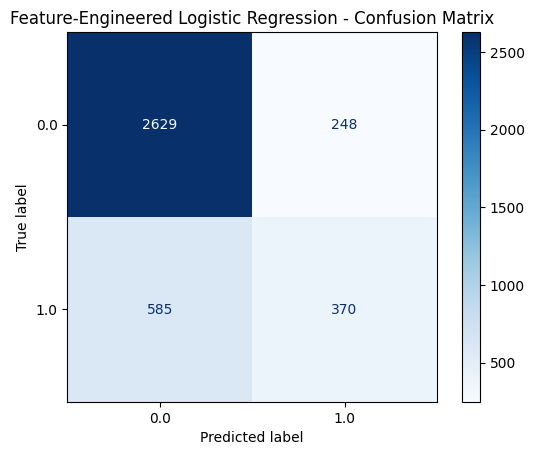

In [24]:
cm_fe = confusion_matrix(y_test, y_pred_fe)
print("Confusion Matrix:\n", cm_fe)

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_fe, cmap="Blues")
plt.title("Feature-Engineered Logistic Regression - Confusion Matrix")
plt.show()

## Step 12: Compare Baseline vs Feature-Engineered

           Baseline  With Engineered Features
Accuracy   0.782359                  0.782620
Precision  0.598374                  0.598706
Recall     0.385340                  0.387435
F1-score   0.468790                  0.470439


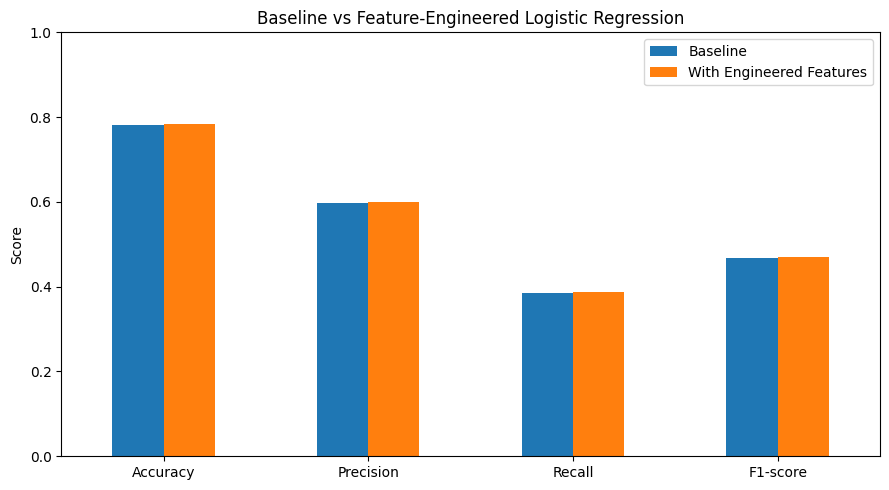

In [25]:
comparison = pd.DataFrame({
    "Baseline": baseline_metrics,
    "With Engineered Features": {"Accuracy": accuracy_fe, "Precision": precision_fe,
                                  "Recall": recall_fe, "F1-score": f1_fe},
})
print(comparison)

comparison.plot(kind="bar", figsize=(9, 5))
plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("Baseline vs Feature-Engineered Logistic Regression")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

---
# KNN (NADIA)


In [26]:
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

In [27]:
# Make column names strings
X_train_encoded.columns = X_train_encoded.columns.astype(str)
X_test_encoded.columns = X_test_encoded.columns.astype(str)

In [28]:
#scalling
scaler = StandardScaler() # mean close to 0 and std = 1
X_train_scaled = scaler.fit_transform(X_train_encoded)
X_test_scaled = scaler.transform(X_test_encoded)


In [29]:
print("Training mean:", X_train_scaled[:, :3].mean(axis=0).round(2))
print("Training std:", X_train_scaled[:, :3].std(axis=0).round(2))

Training mean: [-0. -0. -0.]
Training std: [1. 1. 1.]


In [30]:
print("Training shape:", X_train_scaled.shape)
print("Test shape:", X_test_scaled.shape)

Training shape: (15326, 179)
Test shape: (3832, 179)


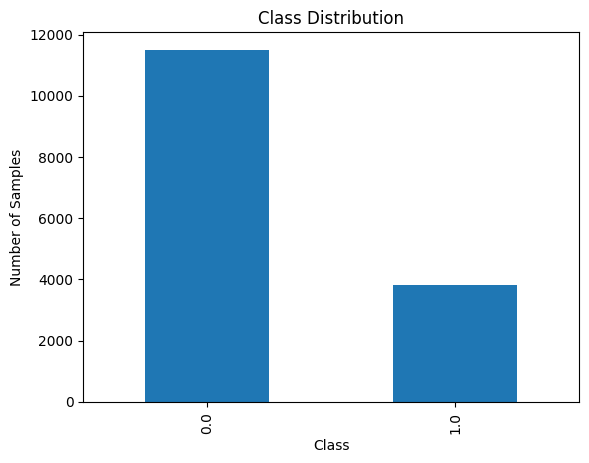

In [31]:
import matplotlib.pyplot as plt
y_train.value_counts().plot(kind='bar')

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.show()

In [32]:
# Test different K values and weighting methods using 5-fold cross-validation
# Uniform: all neighbors have the same effect
# Distance: closer neighbors have more effect
# Use training data only to find the best KNN settings

In [33]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

In [34]:
k_range = range(1, 30, 2)
weights = ["uniform", "distance"]
# Split the data into 5 folds while keeping class proportions
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [35]:
# Test each K and weight
results = []
for weight in weights:
    for k in k_range:
        print(f"Testing K={k}, weights={weight}")

        model = KNeighborsClassifier(
            n_neighbors=k,
            weights=weight
        )
        scores = cross_val_score(
            model,
            X_train_scaled,
            y_train,
            cv=cv,
            scoring="accuracy"
        )
        results.append([k, weight, scores.mean()])

Testing K=1, weights=uniform
Testing K=3, weights=uniform
Testing K=5, weights=uniform
Testing K=7, weights=uniform
Testing K=9, weights=uniform
Testing K=11, weights=uniform
Testing K=13, weights=uniform
Testing K=15, weights=uniform
Testing K=17, weights=uniform
Testing K=19, weights=uniform
Testing K=21, weights=uniform
Testing K=23, weights=uniform
Testing K=25, weights=uniform
Testing K=27, weights=uniform
Testing K=29, weights=uniform
Testing K=1, weights=distance
Testing K=3, weights=distance
Testing K=5, weights=distance
Testing K=7, weights=distance
Testing K=9, weights=distance
Testing K=11, weights=distance
Testing K=13, weights=distance
Testing K=15, weights=distance
Testing K=17, weights=distance
Testing K=19, weights=distance
Testing K=21, weights=distance
Testing K=23, weights=distance
Testing K=25, weights=distance
Testing K=27, weights=distance
Testing K=29, weights=distance


In [36]:
cv_results_df = pd.DataFrame(
    results,
    columns=["K", "Weights", "Accuracy"]
)

cv_results_df.T.style.hide(axis="columns")

K,1,3,5,7,9,11,13,15,17,19,21,23,25,27,29,1,3,5,7,9,11,13,15,17,19,21,23,25,27,29
Weights,uniform,uniform,uniform,uniform,uniform,uniform,uniform,uniform,uniform,uniform,uniform,uniform,uniform,uniform,uniform,distance,distance,distance,distance,distance,distance,distance,distance,distance,distance,distance,distance,distance,distance,distance
Accuracy,0.705664,0.744617,0.761712,0.763735,0.769347,0.771826,0.772544,0.773392,0.773523,0.772805,0.775741,0.776067,0.774828,0.774762,0.774828,0.705664,0.740311,0.756362,0.758058,0.762757,0.765563,0.766933,0.767781,0.767976,0.767781,0.767716,0.768238,0.768564,0.768564,0.768890


In [37]:
best = cv_results_df.loc[cv_results_df["Accuracy"].idxmax()]
print("Best K:", best["K"])
print("Best weights:", best["Weights"])
print("Best accuracy:", best["Accuracy"])

Best K: 23
Best weights: uniform
Best accuracy: 0.7760674194368802


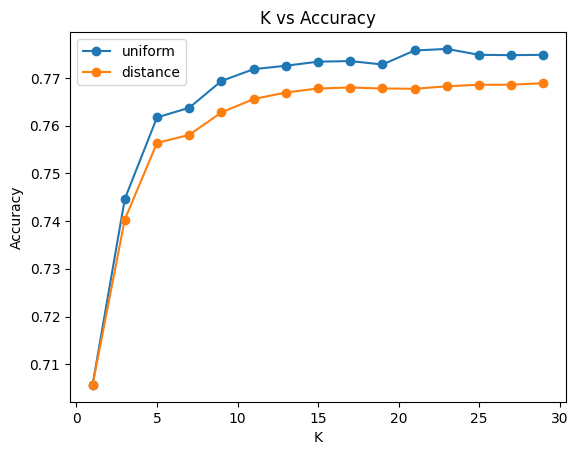

In [38]:
# Compare K values and weighting methods
import matplotlib.pyplot as plt

for weight in weights:
    data = cv_results_df[cv_results_df["Weights"] == weight]
    plt.plot(data["K"], data["Accuracy"], marker="o", label=weight)

plt.xlabel("K")
plt.ylabel("Accuracy")
plt.title("K vs Accuracy")
plt.legend()
plt.show()

In [39]:
#final model train with best k=23
model = KNeighborsClassifier(n_neighbors=23, weights="uniform")
model.fit(X_train_scaled, y_train)

KNeighborsClassifier(n_neighbors=23)

In [40]:
# final test
y_pred = model.predict(X_test_scaled)

In [41]:
# Show predictions
for prediction in y_pred[:10]:
    if prediction == 1:
        print("1 - Looking for a job change")
    else:
        print("0 - Not looking for a job change")

0 - Not looking for a job change
0 - Not looking for a job change
0 - Not looking for a job change
0 - Not looking for a job change
0 - Not looking for a job change
1 - Looking for a job change
0 - Not looking for a job change
0 - Not looking for a job change
0 - Not looking for a job change
0 - Not looking for a job change


In [42]:
# Evaluation
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))

Accuracy: 0.7849686847599165
Precision: 0.5923836389280677
Recall: 0.4397905759162304
F1-score: 0.5048076923076923


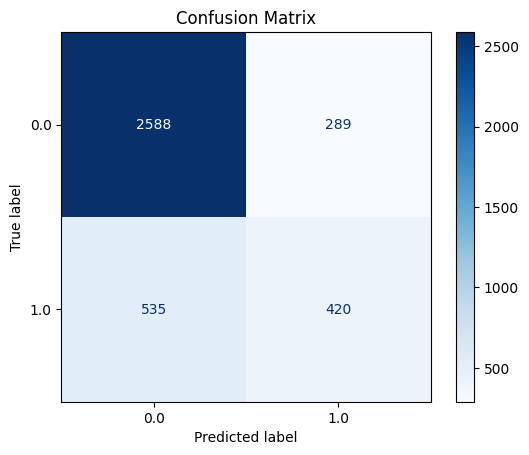

In [43]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.show()

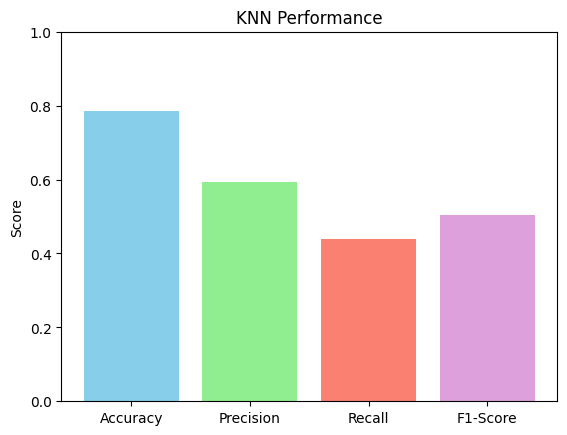

In [44]:
metrics = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1-Score": f1_score(y_test, y_pred)
}

plt.bar(metrics.keys(), metrics.values(), color=["skyblue", "lightgreen", "salmon", "plum"])

plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("KNN Performance")
plt.show()

In [45]:
best_cv_accuracy = max(scores)
test_accuracy = accuracy_score(y_test, y_pred)
print("CV Accuracy:", best_cv_accuracy)
print("Test Accuracy:", test_accuracy)

CV Accuracy: 0.7765089722675367
Test Accuracy: 0.7849686847599165
